<a href="https://colab.research.google.com/github/miguel-duque06/exercicios_introducao_ciencia_dados/blob/main/Analise__exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Explorátoria de Dados 📊
## Dados Nacionais de Segurança Pública - UF

Fonte: https://dados.mj.gov.br/dataset/sistema-nacional-de-estatisticas-de-seguranca-publica/resource/feeae05e-faba-406c-8a4a-512aec91a9d1?view_id=c5f71fec-f048-42c4-864c-60dd611a4984

Sobre a fonte: A base de dados do Sinesp (Sistema Nacional de Informações de Segurança Pública) reúne as estatísticas oficiais de criminalidade do Brasil, unificando os registros de todos os estados.

![NotebookLM Mind Map.png](https://www.gov.br/mj/pt-br/assuntos/noticias/lewandowski-autoriza-envio-de-mais-100-agentes-da-forca-nacional-ao-rs-para-reforcar-seguranca-da-populacao/forca-nacional-1.jfif/@@images/b7f5b602-6ecb-4d9d-adeb-7fe1a322b2e5.jpeg)

### Primeiros passos

* Importando bibliotecas
* Trazendo os dados
* Procurando e corrigindo possíveis erros
* Entendendo os dados
* Buscando informações que ele passa


## Importando bibliotecas


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Trazendo os dados

In [78]:
dados_segurança = pd.read_excel("/content/drive/MyDrive/indicadoressegurancapublicauf.xlsx")

## Procurando e corrigindo possíveis erros


In [79]:
dados_segurança.isnull().sum()

,0
UF,0
Tipo Crime,0
Ano,0
Mês,0
Ocorrências,0


In [80]:
dados_segurança.duplicated().sum()

np.int64(0)

## Entendendo os dados

In [81]:
dados_segurança.shape

(23020, 5)

In [82]:
dados_segurança.columns

Index(['UF', 'Tipo Crime', 'Ano', 'Mês', 'Ocorrências'], dtype='object')

In [83]:
dados_segurança.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23020 entries, 0 to 23019
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   UF           23020 non-null  object
 1   Tipo Crime   23020 non-null  object
 2   Ano          23020 non-null  int64 
 3   Mês          23020 non-null  object
 4   Ocorrências  23020 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 899.3+ KB


## Buscando informações que ele pode me passar

In [84]:
dados_segurança.describe()

,Ano,Ocorrências
count,23020.000000,23020.000000
mean,2018.485447,204.647828
std,2.282230,672.649940
min,2015.000000,0.000000
25%,2016.000000,3.000000
50%,2018.000000,34.000000
75%,2020.000000,169.000000
max,2022.000000,10518.000000


In [85]:
dados_segurança.head()

,UF,Tipo Crime,Ano,Mês,Ocorrências
0,Acre,Estupro,2022,janeiro,31
1,Acre,Furto de veículo,2022,janeiro,50
2,Acre,Homicídio doloso,2022,janeiro,10
3,Acre,Lesão corporal seguida de morte,2022,janeiro,1
4,Acre,Roubo a instituição financeira,2022,janeiro,0


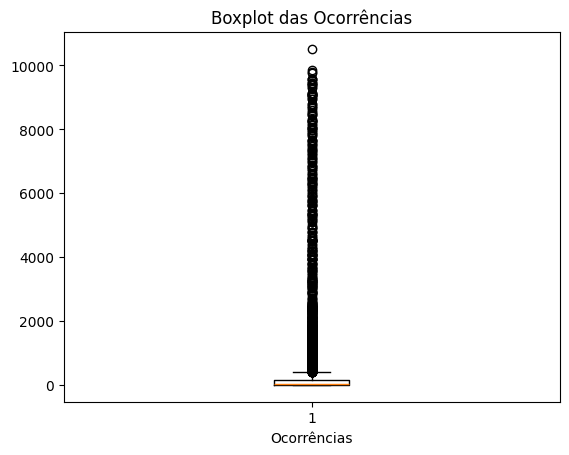

In [86]:
fig, ax = plt.subplots()
ax.boxplot(dados_segurança['Ocorrências'])
ax.set_xlabel('Ocorrências')
plt.title('Boxplot das Ocorrências')
plt.show()


### Tipos de crimes:

In [87]:
valores_tipo_crime = dados_segurança['Tipo Crime'].unique()

In [88]:
valores_tipo_crime

array(['Estupro', 'Furto de veículo', 'Homicídio doloso',
       'Lesão corporal seguida de morte',
       'Roubo a instituição financeira', 'Roubo de carga',
       'Roubo de veículo', 'Roubo seguido de morte (latrocínio)',
       'Tentativa de homicídio'], dtype=object)

### Anos que ocorreram os crimes:

In [89]:
valores_anos = dados_segurança['Ano'].unique()

In [90]:
valores_anos

array([2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015])

## Explorando os dados

* Buscando respostas nos dados
* Comparando e Correlacionando os dados usando gráficos


## Buscando respostas nos dados


### Teve quantas ocorrências nos anos de 2015 a 2022 no Brasil?

In [91]:
dados_segurança['Ocorrências'].sum()

np.int64(4710993)

### Qual é a média de ocorrências de crimes no Brasil?

In [92]:
dados_segurança['Ocorrências'].mean()

np.float64(204.64782797567332)

### Qual foi a maior quantidade de ocorrências do Brasil?

In [93]:
dados_segurança.max()

,0
UF,Tocantins
Tipo Crime,Tentativa de homicídio
Ano,2022
Mês,setembro
Ocorrências,10518


## Comparando e Correlacionando os dados usando gráficos





## Quantas vezes cada tipo de crime ocorreu?

### Objetivo:
Entender qual tipo de crime precisa reforçar o combate

### Comentário:

* Aqui podemos ver que os crimes envolvendo veículos lideram o número de ocorrências registradas. Essa alta demanda ocorre porque o proprietário precisa registrar o fato imediatamente para se isentar de responsabilidade caso o criminoso cometa infrações ou outros delitos com o automóvel. Outro fator determinante é a exigência do Boletim de Ocorrência para acionar a seguradora do veículo.


In [94]:
dados_segurança.groupby('Tipo Crime')['Ocorrências'].sum().reset_index()

,Tipo Crime,Ocorrências
0,Estupro,406831
1,Furto de veículo,1851837
2,Homicídio doloso,354868
3,Lesão corporal seguida de morte,6100
4,Roubo a instituição financeira,5298
5,Roubo de carga,148342
6,Roubo de veículo,1633495
7,Roubo seguido de morte (latrocínio),14263
8,Tentativa de homicídio,289959


In [95]:
grafico_tc_ocs = dados_segurança.groupby('Tipo Crime')['Ocorrências'].sum().reset_index()

fig = px.bar(grafico_tc_ocs,
             x='Tipo Crime',
             y='Ocorrências',
             title='Ocorrências por Tipo Crime'
             )

fig.show()

## Quantas ocorrências tem em cada UF?

### Objetivo:
Aumentar o policiamento nas UFs que mais precisam



### Comentário:
Esta comparação de dados está enviesada, pois desconsidera o tamanho da população de cada UF, impedindo uma análise proporcional.

In [96]:
dados_segurança.groupby('UF')['Ocorrências'].sum().sort_values().reset_index()

,UF,Ocorrências
0,Amapá,13954
1,Acre,14356
2,Roraima,14782
3,Tocantins,28804
4,Paraíba,36682
5,Sergipe,41088
6,Rondônia,50927
7,Alagoas,51749
8,Mato Grosso do Sul,57158
9,Amazonas,59178


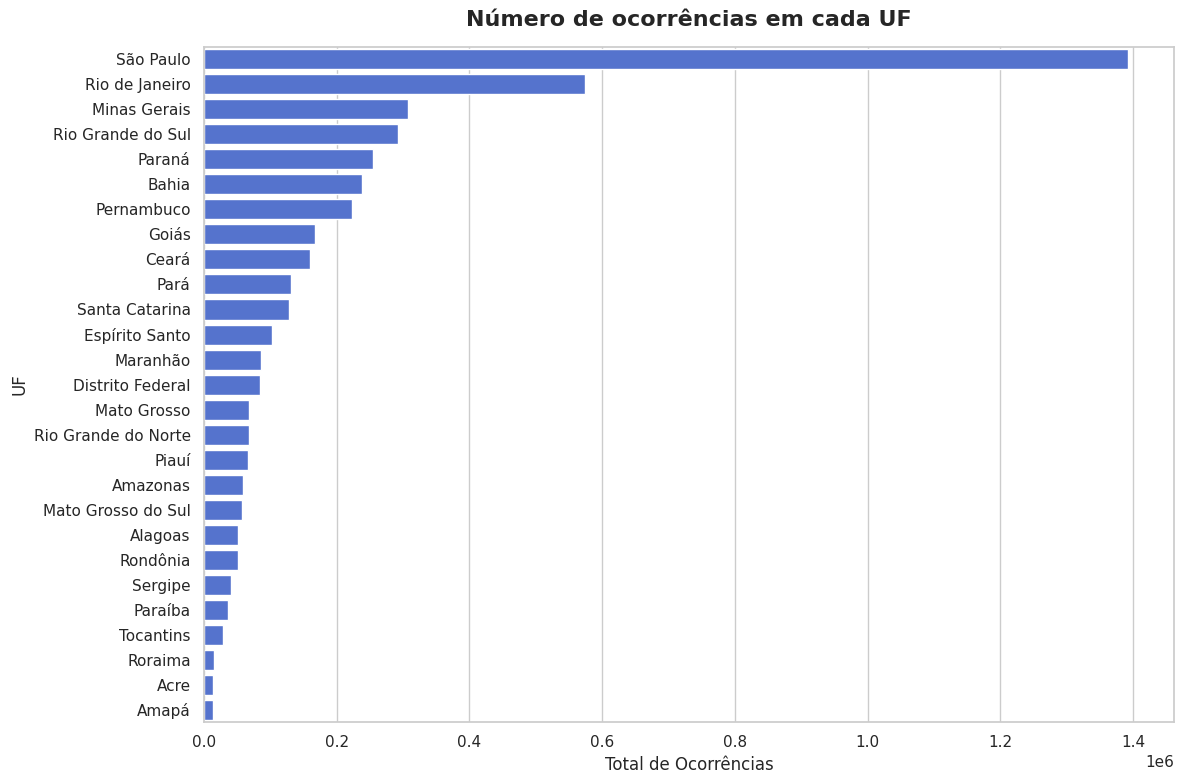

In [103]:
grafico_uf_ocs = dados_segurança.groupby('UF')['Ocorrências'].sum().sort_values().reset_index()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

sns.barplot(
    data=grafico_uf_ocs.sort_values(by='Ocorrências', ascending=False),
    x='Ocorrências',
    y='UF',
    color='royalblue'
)

plt.title('Número de ocorrências em cada UF', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total de Ocorrências', fontsize=12)
plt.ylabel('UF', fontsize=12)

plt.tight_layout()
plt.show()

## Quantas ocorrências tem em cada UF proporcional a sua população?

### Objetivo:
Aumentar o número de concurso para policial nas UFs que mais precisam aumentar a segurança



### Comentário:
* Aqui observa-se que a análise ficou mais equilibrada após o cálculo da taxa proporcional ($\text{Ocorrências} \div \text{População} \times 100.000$)

* Embora os dados brutos sugerissem que São Paulo era o estado mais perigoso devido ao maior volume de registros, a taxa proporcional revelou o Rio de Janeiro no topo do ranking e São Paulo na terceira posição

* Com esse resultado, fica evidente que a segurança do Rio de Janeiro precisa de atenção, ao mesmo tempo em que se observa que os demais estados não estão em uma situação muito mais segura

In [98]:
#Trazendo dataset das populações para deixar a análise proporcional

dados_populações = pd.read_csv('/content/drive/MyDrive/dados-populacao.txt', sep=';')
dados_populações = dados_populações.drop(columns=['Sigla', 'Regiao'])

grafico_pop_ocs = pd.merge(dados_populações,
                           grafico_uf_ocs,
                           left_on='Estado',
                           right_on='UF'
                           )


grafico_pop_ocs = grafico_pop_ocs.drop(columns=['Estado'])

grafico_pop_ocs['Ocorrencias_Proporcionais'] = (grafico_pop_ocs['Ocorrências'] / grafico_pop_ocs['Populacao']) * 100000

grafico_pop_ocs = grafico_pop_ocs.drop(columns=['Ocorrências', 'Populacao'])

grafico_pop_ocs

,UF,Ocorrencias_Proporcionais
0,Acre,1729.638554
1,Alagoas,1658.621795
2,Amapá,1903.683492
3,Amazonas,1501.979695
4,Bahia,1679.229137
5,Ceará,1816.769056
6,Distrito Federal,2996.654804
7,Espírito Santo,2664.986945
8,Goiás,2384.624113
9,Maranhão,1270.059084


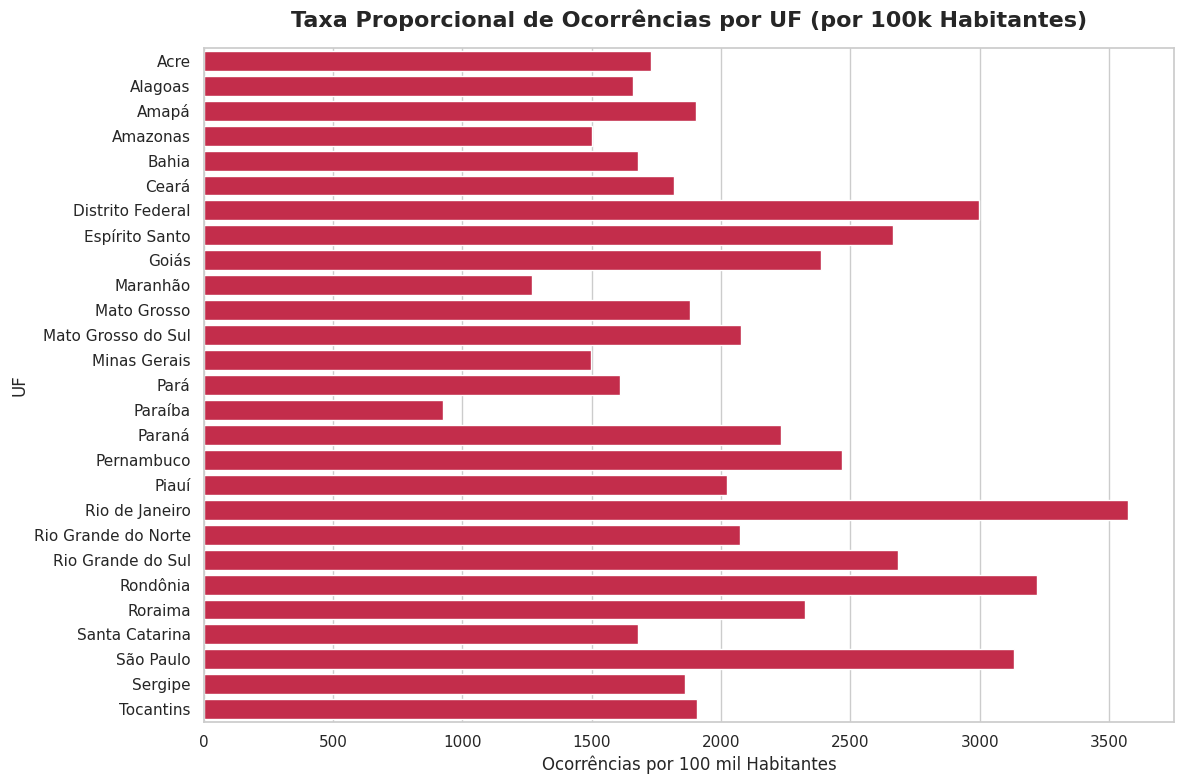

In [105]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

sns.barplot(
    data=grafico_pop_ocs,
    x='Ocorrencias_Proporcionais',
    y='UF',
    color='crimson'
)

# 5. Títulos e legendas dos eixos
plt.title('Taxa Proporcional de Ocorrências por UF (por 100k Habitantes)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Ocorrências por 100 mil Habitantes', fontsize=12)
plt.ylabel('UF', fontsize=12)

# 6. Ajusta o espaçamento das bordas e exibe
plt.tight_layout()
plt.show()

## Qual a evolução anual das ocorrências?

### Objetivo:
Buscar anos que possam servir de referência para a segurança

### Comentários:
* O ano de 2020 foi marcado pelo início da pandemia da COVID-19 e pelas medidas de isolamento social. Com as pessoas trancadas em casa, o comércio fechado e muito menos veículos circulando nas ruas, as oportunidades para os crimes patrimoniais (que vimos no gráfico anterior que dominam os volumes, como furtos e roubos de veículos) caíram drasticamente. É a famosa "queda artificial" gerada pela mudança radical na rotina das cidades.

* Após tocar o fundo em 2020, a linha volta a subir de forma gradual em 2021 e ganha tração em 2022, aproximando-se da marca de 500 mil ocorrências.

* Esse movimento representa o cenário de retomada das atividades presenciais e o fim do isolamento. Com a volta do fluxo normal de pessoas e carros nas ruas, a atividade criminosa começou a retomar os padrões anteriores, embora o patamar de 2022 ainda permaneça bem abaixo dos anos críticos de 2016 e 2017.

* Apesar de todas esses casos fora do comun o ano de 2018 e 2019 pode ser um ano que pode ser usados como exemplo

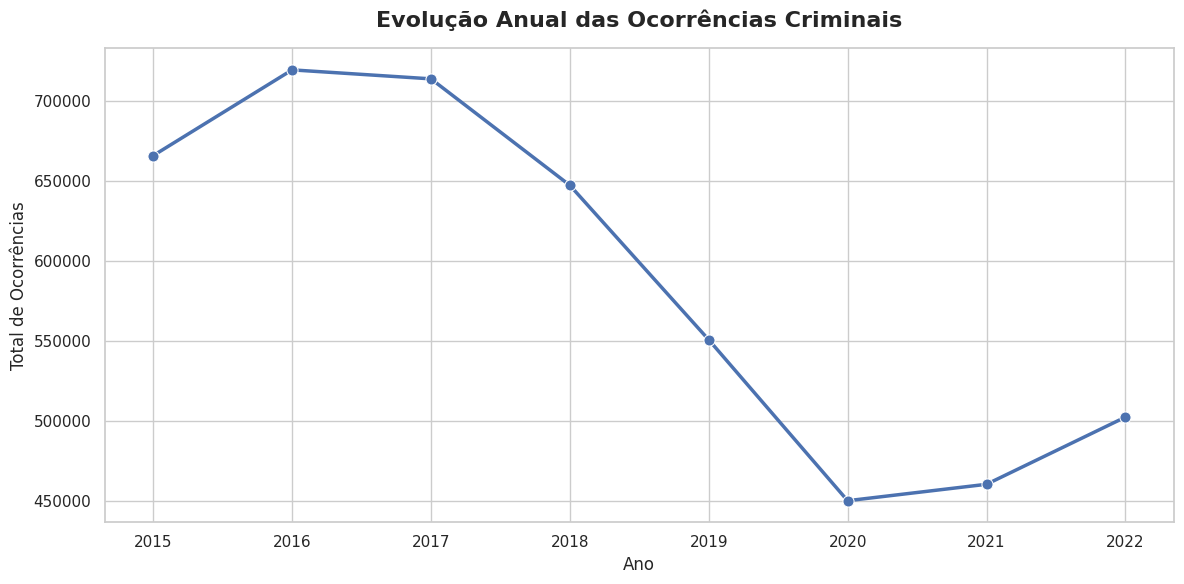

In [106]:
grafico_ano_ocs = dados_segurança.groupby('Ano')['Ocorrências'].sum().reset_index()

grafico_ano_ocs['Ano'] = grafico_ano_ocs['Ano'].astype(str)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# 3. Cria o gráfico de linha
sns.lineplot(
    data=grafico_ano_ocs,
    x='Ano',
    y='Ocorrências',
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='b'
)

plt.title('Evolução Anual das Ocorrências Criminais', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Total de Ocorrências', fontsize=12)

anos_unicos = grafico_ano_ocs['Ano'].unique()
plt.xticks(anos_unicos)

plt.tight_layout()
plt.show()

## Qual a evolução mensal das ocorrências?

### Objetivo:
Buscar entender em quais meses reforçar a segurança
### Comentários:

* Durante os dias de Carnaval, muitas delegacias operam em regime de plantão e as pessoas evitam registrar ocorrências menores (como furtos de celular ou documentos) no meio da festa. Elas deixam para fazer o Boletim de Ocorrência na semana ou nas semanas seguintes, o que joga o volume de registros oficialmente para o mês de março.

* Mais dias no mês significam, matematicamente, mais tempo para os crimes acontecerem e serem registrados.

* Mais pessoas circulando nas ruas, no transporte público e no comércio criam mais oportunidades para crimes patrimoniais (roubos e furtos).

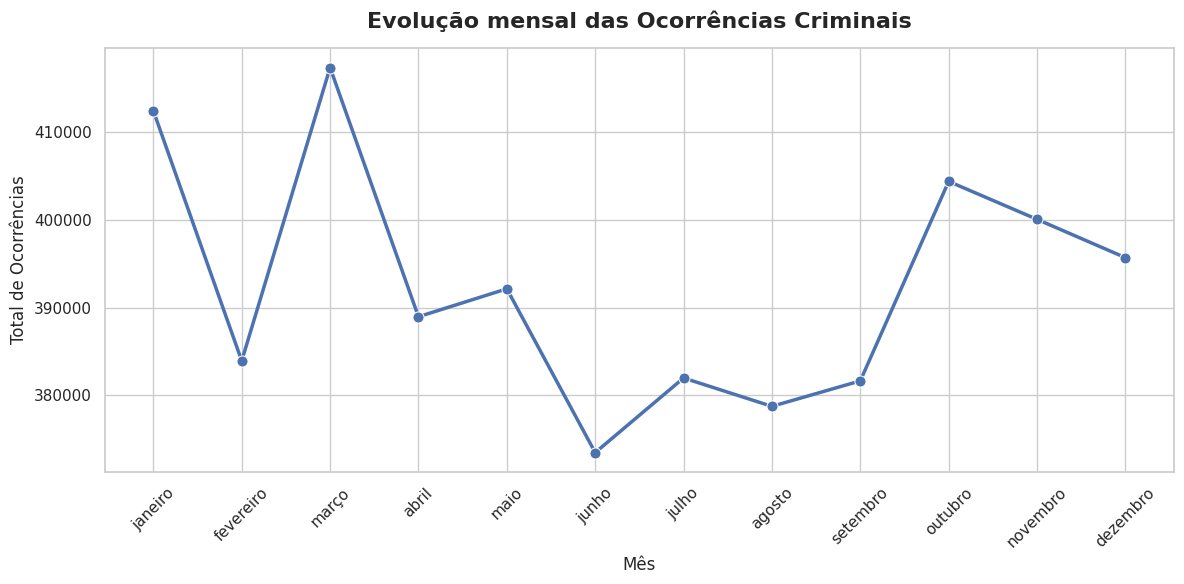

In [107]:
# Lista com a ordem natural dos meses
ordem_meses = ['janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho',
               'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro']

grafico_mes_ocs = dados_segurança.groupby('Mês', observed=False)['Ocorrências'].sum().reset_index()

grafico_mes_ocs['Mês'] = pd.Categorical(grafico_mes_ocs['Mês'], categories=ordem_meses, ordered=True)

grafico_mes_ocs = grafico_mes_ocs.sort_values('Mês').reset_index(drop=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=grafico_mes_ocs,
    x='Mês',
    y='Ocorrências',
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='b'
)

plt.title('Evolução mensal das Ocorrências Criminais', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Total de Ocorrências', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()